In [6]:
import pandas as pd
from glob import glob


results_list = glob("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/brca/results/*.csv")
len(results_list)

97

In [7]:
results_df_list = []
for result in results_list:
    df = pd.read_csv(result, index_col=0)
    results_df_list.append(df)

In [8]:
AB_pair = results_df_list[0][["A", "B"]]
AB_pair

,A,B
164,IgG plasma cell,macrophage
172,IgG plasma cell,neutrophil
175,IgG plasma cell,plasmacytoid dendritic cell
628,macrophage,neutrophil
715,neutrophil,plasmacytoid dendritic cell
...,...,...
425,conventional dendritic cell,macrophage
691,myeloid dendritic cell,plasmacytoid dendritic cell
625,macrophage,myeloid dendritic cell
154,IgG plasma cell,conventional dendritic cell


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_distribution(observations, save_path):
    A = observations

    # Set the plot style and context for scientific paper
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.5)

    # Sample data: replace this with your list A containing 100 observations
    # A = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] * 10

    # Calculate mean
    mean_val = np.mean(A)

    # Create a larger figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the distribution curve
    sns.distplot(A, hist=False, kde=True, kde_kws={'linewidth': 2.5}, ax=ax)

    # Customize the plot
    ax.set_title('Distribution of R_val for cellA with cellB')
    ax.set_xlabel('R_val')
    ax.set_ylabel('Density')

    # Add a dashed vertical line at the mean value with a custom darker blue color
    ax.axvline(mean_val, linestyle='--', color=(0.3, 0.6, 1), label=f'Mean: {mean_val:.2f}')
    ax.legend()

    # Set a tight layout
    plt.tight_layout()

    # Save the plot as a high-quality image
    plt.savefig(save_path)

/tmp/ipykernel_979527/3762949506.py:22: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(A, hist=False, kde=True, kde_kws={'linewidth': 2.5}, ax=ax)
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before op

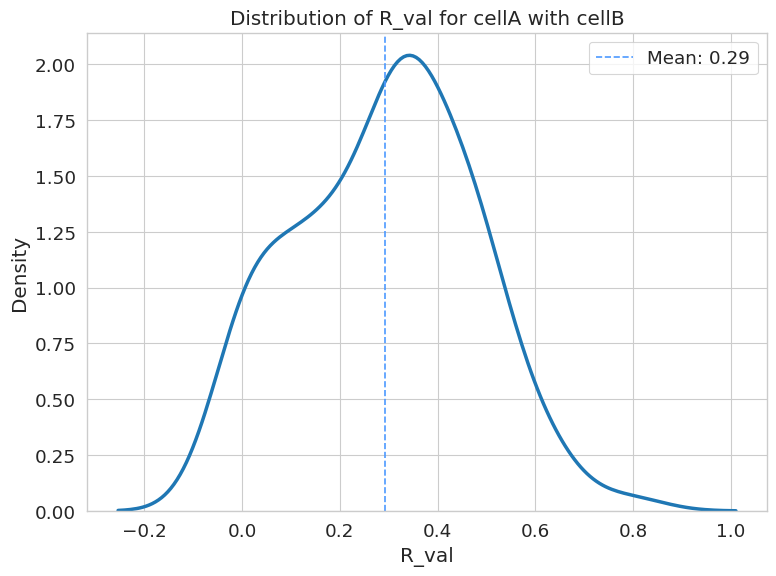

In [5]:
import os
import numpy as np


for row in AB_pair.iterrows():
    A = row[1]["A"]
    B = row[1]["B"]
    score_list = []
    for df in results_df_list:
        score = df[(df["A"]==A)&(df["B"]==B)]["R_val"].values[0]
        score_list.append(score)
    
    average_score = np.mean(score_list)
    save_path = os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/brca/distribution_plots", f"{average_score:.3f}"+"_"+A+"_"+B+".png")
    
    plot_distribution(observations=score_list, save_path=save_path)

In [10]:
results_df_list[0]

,A,B,R_val,R_z_score,R_p_val
164,IgG plasma cell,macrophage,0.792164,427.302769,0.0
172,IgG plasma cell,neutrophil,0.790334,426.315889,0.0
175,IgG plasma cell,plasmacytoid dendritic cell,0.785384,423.645683,0.0
628,macrophage,neutrophil,0.763466,411.822936,0.0
715,neutrophil,plasmacytoid dendritic cell,0.760425,410.182494,0.0
...,...,...,...,...,...
425,conventional dendritic cell,macrophage,-0.641440,-346.000392,1.0
691,myeloid dendritic cell,plasmacytoid dendritic cell,-0.643204,-346.952242,1.0
625,macrophage,myeloid dendritic cell,-0.650387,-350.826451,1.0
154,IgG plasma cell,conventional dendritic cell,-0.672194,-362.589429,1.0


In [11]:
# Concatenate the DataFrames in the list
concatenated_df = pd.concat(results_df_list, ignore_index=True)
concatenated_df

,A,B,R_val,R_z_score,R_p_val
0,IgG plasma cell,macrophage,0.792164,427.302769,0.0
1,IgG plasma cell,neutrophil,0.790334,426.315889,0.0
2,IgG plasma cell,plasmacytoid dendritic cell,0.785384,423.645683,0.0
3,macrophage,neutrophil,0.763466,411.822936,0.0
4,neutrophil,plasmacytoid dendritic cell,0.760425,410.182494,0.0
...,...,...,...,...,...
71872,"activated CD8-positive, alpha-beta T cell",mammary gland epithelial cell,-0.135936,-84.915892,1.0
71873,alternatively activated macrophage,mammary gland epithelial cell,-0.142443,-88.980629,1.0
71874,"effector memory CD4-positive, alpha-beta T cell",vascular associated smooth muscle cell,-0.150819,-94.213228,1.0
71875,IgA plasma cell,alternatively activated macrophage,-0.152707,-95.392564,1.0


In [12]:
# Group by columns A and B and calculate the mean of each group
average_df = concatenated_df.groupby(['A', 'B']).mean().reset_index()
average_df = average_df.sort_values('R_val', ascending=False)
average_df

,A,B,R_val,R_z_score,R_p_val
715,neutrophil,plasmacytoid dendritic cell,0.343270,168.961597,2.061856e-02
175,IgG plasma cell,plasmacytoid dendritic cell,0.341451,168.043479,3.931816e-24
172,IgG plasma cell,neutrophil,0.336520,165.428466,7.219656e-02
111,IgA plasma cell,IgG plasma cell,0.313255,154.562749,2.122142e-02
628,macrophage,neutrophil,0.307205,152.529167,2.309178e-02
...,...,...,...,...,...
247,"activated CD8-positive, alpha-beta T cell",capillary endothelial cell,-0.096148,-52.491460,8.681172e-01
109,"CD8-positive, alpha-beta memory T cell",vascular associated smooth muscle cell,-0.096819,-50.125034,7.918842e-01
121,IgA plasma cell,"effector memory CD4-positive, alpha-beta T cell",-0.128520,-60.541353,8.348849e-01
450,"effector memory CD4-positive, alpha-beta T cell",mammary gland epithelial cell,-0.129479,-63.115331,8.954887e-01


In [13]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns


df_figure = average_df[['A', 'B', 'R_val']]
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iloc[-1, -1] = 1.0
cell2location_cluster = sns.clustermap(correlation_df, figsize=(20, 20), cmap="viridis")
row_linkage = cell2location_cluster.dendrogram_row.linkage
col_linkage = cell2location_cluster.dendrogram_col.linkage
plt.savefig("brca_overall_Hist2Cell_clustermap.svg", bbox_inches='tight', pad_inches=0)
plt.close()

In [14]:
average_df

,A,B,R_val,R_z_score,R_p_val
715,neutrophil,plasmacytoid dendritic cell,0.343270,168.961597,2.061856e-02
175,IgG plasma cell,plasmacytoid dendritic cell,0.341451,168.043479,3.931816e-24
172,IgG plasma cell,neutrophil,0.336520,165.428466,7.219656e-02
111,IgA plasma cell,IgG plasma cell,0.313255,154.562749,2.122142e-02
628,macrophage,neutrophil,0.307205,152.529167,2.309178e-02
...,...,...,...,...,...
247,"activated CD8-positive, alpha-beta T cell",capillary endothelial cell,-0.096148,-52.491460,8.681172e-01
109,"CD8-positive, alpha-beta memory T cell",vascular associated smooth muscle cell,-0.096819,-50.125034,7.918842e-01
121,IgA plasma cell,"effector memory CD4-positive, alpha-beta T cell",-0.128520,-60.541353,8.348849e-01
450,"effector memory CD4-positive, alpha-beta T cell",mammary gland epithelial cell,-0.129479,-63.115331,8.954887e-01


In [15]:
import pandas as pd

seleted_label_df = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/brca/selected_label_df.csv", index_col=0)
abundance_df = pd.DataFrame(seleted_label_df.sum(axis=0), columns=["abundance"])
abundance_df.head(5)

,abundance
q05cell_abundance_w_sf_CD4-positive helper T cell,20.047012
"q05cell_abundance_w_sf_CD4-positive, alpha-beta T cell",67.553469
"q05cell_abundance_w_sf_CD8-positive, alpha-beta memory T cell",11.088328
q05cell_abundance_w_sf_IgA plasma cell,50.805477
q05cell_abundance_w_sf_IgG plasma cell,161.472248


In [16]:
import pandas as pd

cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/A1/cell_ratio.csv").columns)[1:]]
cell_names[:5]

['CD4-positive helper T cell',
 'CD4-positive, alpha-beta T cell',
 'CD8-positive, alpha-beta memory T cell',
 'IgA plasma cell',
 'IgG plasma cell']

In [17]:
abundance_df.index = cell_names
abundance_df.head(5)

,abundance
CD4-positive helper T cell,20.047012
"CD4-positive, alpha-beta T cell",67.553469
"CD8-positive, alpha-beta memory T cell",11.088328
IgA plasma cell,50.805477
IgG plasma cell,161.472248


In [18]:
average_df['abundance_product'] = 0.0
average_df['index'] = average_df['A'] + ' and ' + average_df['B']
average_df.set_index('index', inplace=True)
average_df.head(5)

,A,B,R_val,R_z_score,R_p_val,abundance_product
index,,,,,,
neutrophil and plasmacytoid dendritic cell,neutrophil,plasmacytoid dendritic cell,0.343270,168.961597,2.061856e-02,0.0
IgG plasma cell and plasmacytoid dendritic cell,IgG plasma cell,plasmacytoid dendritic cell,0.341451,168.043479,3.931816e-24,0.0
IgG plasma cell and neutrophil,IgG plasma cell,neutrophil,0.336520,165.428466,7.219656e-02,0.0
IgA plasma cell and IgG plasma cell,IgA plasma cell,IgG plasma cell,0.313255,154.562749,2.122142e-02,0.0
macrophage and neutrophil,macrophage,neutrophil,0.307205,152.529167,2.309178e-02,0.0


In [19]:
for row in average_df.iterrows():
    A = row[1]["A"]
    B = row[1]["B"]
    A_abundance = abundance_df.loc[A]["abundance"]
    B_abundance = abundance_df.loc[B]["abundance"]
    abundance_product = A_abundance * B_abundance
    average_df.loc[row[0], "abundance_product"] = abundance_product
    
average_df.head(5)
    

,A,B,R_val,R_z_score,R_p_val,abundance_product
index,,,,,,
neutrophil and plasmacytoid dendritic cell,neutrophil,plasmacytoid dendritic cell,0.343270,168.961597,2.061856e-02,3911.583615
IgG plasma cell and plasmacytoid dendritic cell,IgG plasma cell,plasmacytoid dendritic cell,0.341451,168.043479,3.931816e-24,11438.639542
IgG plasma cell and neutrophil,IgG plasma cell,neutrophil,0.336520,165.428466,7.219656e-02,8916.081473
IgA plasma cell and IgG plasma cell,IgA plasma cell,IgG plasma cell,0.313255,154.562749,2.122142e-02,8203.674601
macrophage and neutrophil,macrophage,neutrophil,0.307205,152.529167,2.309178e-02,15203.140261


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


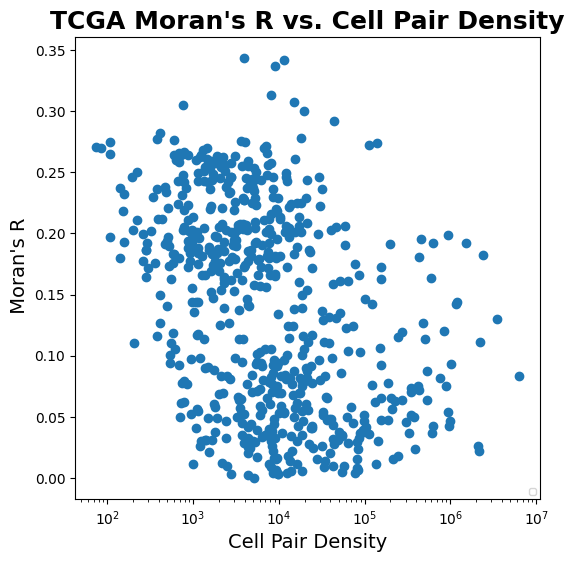

In [20]:
import matplotlib.pyplot as plt

# Filter out the points with y-values less than 0.0
filtered_df = average_df.query('R_val > 0.0')

label_list = filtered_df.index

# Create a scatter plot
plt.figure(figsize=(6, 6))  # Set the figure size

# 使用过滤后的数据绘制散点图，并为每个点添加名称
plt.scatter(x=filtered_df['abundance_product'], y=filtered_df['R_val'])

# Set the title and axis labels
plt.title("TCGA Moran's R vs. Cell Pair Density", fontsize=18, fontweight='bold')
plt.xlabel("Cell Pair Density", fontsize=14)
plt.ylabel(' Moran\'s R', fontsize=14)

# 设置X轴为对数坐标轴
plt.xscale('log')

# 显示图例
plt.legend(fontsize=6, loc='lower right')

# Show the plot
plt.show()

In [21]:
moran_list = filtered_df['R_val'].to_list()
density_list = filtered_df['abundance_product'].to_list()
label_list = filtered_df.index.to_list()

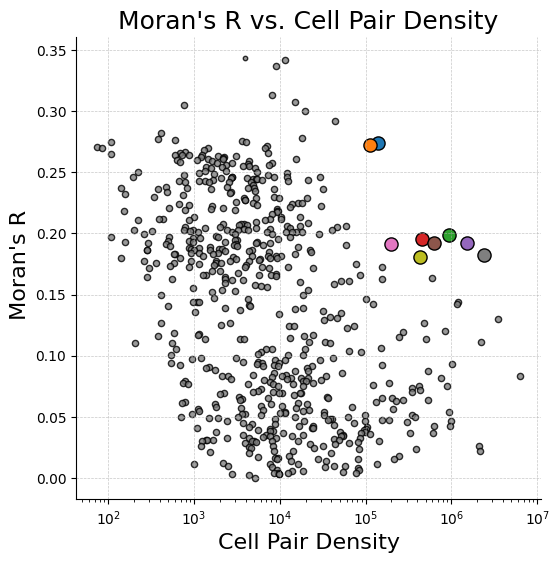

In [40]:
import matplotlib.pyplot as plt
import os


# Filter out the points with y-values less than 0.0
moran_list = filtered_df['R_val'].to_list()
density_list = filtered_df['abundance_product'].to_list()
label_list = filtered_df.index.to_list()

# 过滤moran小于0.0的点
filtered_data = [(density, moran, pair_name) for density, moran, pair_name in zip(density_list, moran_list, label_list) if moran > 0.0]

# Create a scatter plot
plt.figure(figsize=(6, 6))  # Set the figure size


label_list = []
# 使用过滤后的数据绘制散点图，并为每个点添加名称
other_label_added = False
for density, moran, pair_name in filtered_data:
    if moran > 0.18 and density > 1e5:
        plt.scatter(x=density, y=moran, label=pair_name, s=90, edgecolor='black')
        label_list.append(pair_name)
    else:
        if not other_label_added:
            plt.scatter(x=density, y=moran, label="other", c="grey", s=10, alpha=0.8, edgecolor='black')
            other_label_added = True
            label_list.append("other")
        else:
            plt.scatter(x=density, y=moran, c="grey", s=20, alpha=0.8, edgecolor='black')


# Set the title and axis labels
plt.title("Moran's R vs. Cell Pair Density", fontsize=18)
plt.xlabel("Cell Pair Density", fontsize=16)
plt.ylabel(' Moran\'s R', fontsize=16)

# 设置X轴为对数坐标轴
plt.xscale('log')

# Customize the grid and axis appearance
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 显示图例
# plt.legend(fontsize=6, loc='lower right')

# Set the color of x-axis and y-axis lines to black
ax = plt.gca()
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# Remove the top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show the plot
plt.savefig(os.path.join("brca_moransR_vs_cellpair_density.svg"), bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

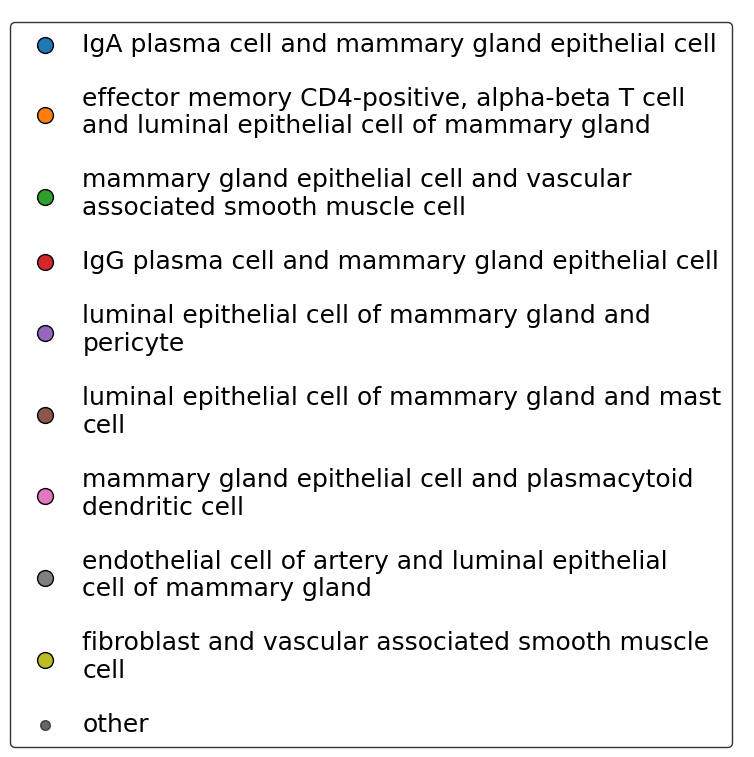

In [41]:
import textwrap

def wrap_labels(ax, width=40):
    """将图例标签换行的函数"""
    labels = [textwrap.fill(label.get_text(), width) for label in ax.get_legend().get_texts()]
    ax.legend(labels, loc="best", labelspacing=1.2, handletextpad=0.5, handlelength=2, fontsize=18, edgecolor='black')

# 然后创建并保存仅包含图例的图
fig_legend = plt.figure(figsize=(4, 5))
ax_legend = fig_legend.add_subplot(111)
# 使用同样的label和color创建一个空的散点图来生成图例
for label in label_list:
    if label == "other":
        continue
    ax_legend.scatter([], [], label=label, s=130, edgecolor='black')
ax_legend.scatter([], [], label="other", c="black", s=50, alpha=0.6, edgecolor='black')

# 生成图例
ax_legend.legend(fontsize=18, loc='center')
ax_legend.axis('off')

# 调用wrap_labels函数
wrap_labels(ax_legend, width=50)  # 可以调整width以适合您的需求

# Show the plot
plt.savefig("brca_moransR_vs_cellpair_density_legend.svg", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close(fig_legend)